# High-End Corporate Tax Planning Optimization Model
### Case Study: Aether Global Group (Multi-Jurisdiction & Multi-Industry)

This Google Colab notebook implements an interactive tax planning simulator modeling corporate income taxes, intercompany transactions, transfer pricing, and modern anti-avoidance frameworks (such as **US GILTI** and **OECD Pillar Two Global Minimum Tax**).

---

## 1. Architectural Math & Regulatory Rules

### 1A. Corporate Income Tax (CIT)
The local taxable income for each subsidiary is calculated by adjusting local operating profit with intercompany inflows and outflows:

\[ T_i = \text{OpProfit}_i + \text{RoyaltyIn}_i + \text{InterestIn}_i + \text{TPProfit}_i - \text{RoyaltyOut}_i - \text{InterestOut}_i - \text{TPCost}_i \]

### 1B. Thin-Capitalization Limit (Interest Caps)
Intercompany interest deduction is capped at 30% of EBITDA to prevent profit shifting via excessive debt:

\[ \text{InterestOut}_{\text{allowable}} = \max\left(0, \text{EBITDA}_i \times 0.30\right) \]
Any interest paid above this limit is added back to taxable income \( T_i \) and flagged as high audit risk.

### 1C. Controlled Foreign Corporation (CFC) / US GILTI Rules
US parent taxes the low-taxed intangible income of foreign subsidiaries. An 80% Foreign Tax Credit (FTC) is allowed:

\[ \text{GILTI Tax} = \max\left(0, (\text{TaxableIncome}_{CFC} - \text{QBAI} \times 10\%) \times 50\% \times 21\% - \text{LocalTax} \times 80\%\right) \]

### 1D. OECD Pillar Two (15% Global Minimum Tax)
If the Effective Tax Rate (ETR) in a jurisdiction falls below 15%:

\[ \text{Top-Up Tax Rate} = 15\% - \text{ETR}_{local} \]
\[ \text{SBIE} = 5\% \times \text{Payroll} + 5\% \times \text{TangibleAssets} \]
\[ \text{Top-Up Tax} = \text{Top-Up Tax Rate} \times \max(0, T_i - \text{SBIE}) \]

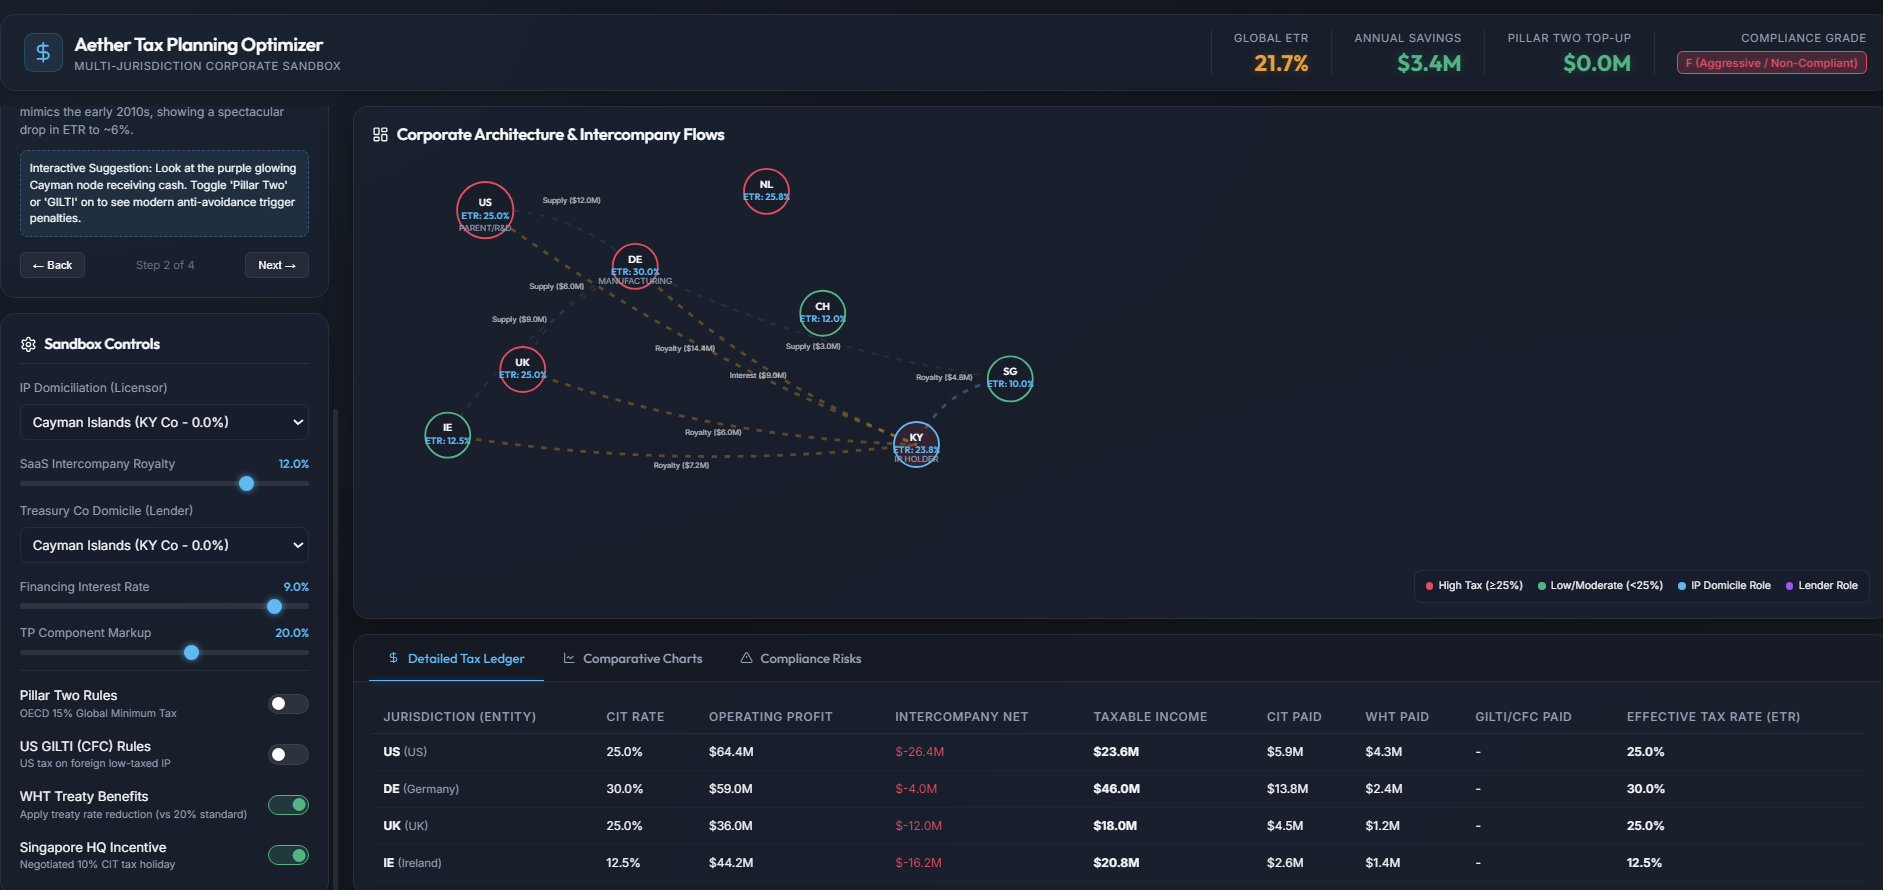

In [2]:
# Install and import visualization and widget packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interactive

sns.set_theme(style="darkgrid")
plt.rcParams["figure.facecolor"] = "#0f172a"
plt.rcParams["axes.facecolor"] = "#1e293b"
plt.rcParams["text.color"] = "#f8fafc"
plt.rcParams["axes.labelcolor"] = "#94a3b8"
plt.rcParams["xtick.color"] = "#94a3b8"
plt.rcParams["ytick.color"] = "#94a3b8"
plt.rcParams["grid.color"] = (1.0, 1.0, 1.0, 0.05)

In [3]:
class TaxEngine:
    def __init__(self):
        # Base financial data per entity
        self.base_entities = {
            "US": {"name": "US Co (Parent & R&D)", "cit_rate": 0.25, "local_rev": 120000000, "local_opex": 40000000, "rd": 30000000, "payroll": 25000000, "assets": 15000000},
            "DE": {"name": "Germany GmbH (Mfg)", "cit_rate": 0.30, "local_rev": 80000000, "local_opex": 25000000, "rd": 5000000, "payroll": 22000000, "assets": 45000000},
            "UK": {"name": "UK Ltd (Services)", "cit_rate": 0.25, "local_rev": 50000000, "local_opex": 20000000, "rd": 0, "payroll": 12000000, "assets": 5000000},
            "IE": {"name": "Ireland Ltd (EU Sales)", "cit_rate": 0.125, "local_rev": 60000000, "local_opex": 15000000, "rd": 8000000, "payroll": 10000000, "assets": 8000000},
            "CH": {"name": "Switzerland AG (HQ)", "cit_rate": 0.12, "local_rev": 30000000, "local_opex": 10000000, "rd": 2000000, "payroll": 6000000, "assets": 4000000},
            "SG": {"name": "Singapore Pte (APAC)", "cit_rate": 0.17, "local_rev": 40000000, "local_opex": 12000000, "rd": 0, "payroll": 8000000, "assets": 3000000},
            "NL": {"name": "Netherlands BV (Holding)", "cit_rate": 0.258, "local_rev": 0, "local_opex": 2000000, "rd": 0, "payroll": 800000, "assets": 1000000},
            "KY": {"name": "Cayman Ltd (Shell)", "cit_rate": 0.0, "local_rev": 0, "local_opex": 100000, "rd": 0, "payroll": 0, "assets": 0}
        }

        # Treaty WHT rates Matrix: Source -> Destination
        self.wht_rates = {
            "US": {"IE": 0.0, "CH": 0.0, "KY": 0.30, "SG": 0.10, "NL": 0.0},
            "DE": {"IE": 0.0, "CH": 0.0, "KY": 0.263, "SG": 0.05, "NL": 0.0},
            "UK": {"IE": 0.0, "CH": 0.0, "KY": 0.20, "SG": 0.08, "NL": 0.0},
            "IE": {"CH": 0.0, "KY": 0.20, "SG": 0.0, "NL": 0.0, "US": 0.05},
            "CH": {"IE": 0.0, "KY": 0.0, "SG": 0.0, "NL": 0.0, "US": 0.05},
            "SG": {"IE": 0.0, "CH": 0.0, "KY": 0.10, "NL": 0.0, "US": 0.10},
            "NL": {"IE": 0.0, "CH": 0.0, "KY": 0.258, "SG": 0.0, "US": 0.05}
        }

    def get_wht(self, source, dest, rule_treaty):
        if source == dest:
            return 0.0
        if not rule_treaty:
            return 0.20 # High standard statutory fallback
        return self.wht_rates.get(source, {}).get(dest, 0.20)

    def simulate(self, ip_dom, royalty_rate, fin_dom, interest_rate, tp_markup, rule_p2, rule_gilti, rule_treaty, sg_incentive):
        entities = {code: dict(val) for code, val in self.base_entities.items()}
        for code in entities:
            entities[code].update({
                "code": code, "royalty_in": 0.0, "royalty_out": 0.0, "interest_in": 0.0, "interest_out": 0.0,
                "tp_in": 0.0, "tp_out": 0.0, "taxable": 0.0, "cit": 0.0, "wht": 0.0, "gilti": 0.0,
                "p2_topup": 0.0, "total_tax": 0.0, "net": 0.0
            })

        entities["SG"]["cit_rate"] = 0.10 if sg_incentive else 0.17

        # 1. TP Component Sales (Germany Co -> Subs)
        tp_cogs = 25000000
        tp_sales = tp_cogs * (1 + tp_markup)
        entities["DE"]["tp_in"] = tp_sales - tp_cogs
        entities["DE"]["local_rev"] += tp_sales
        entities["DE"]["local_opex"] += tp_cogs

        tp_dist = {"US": 0.4, "UK": 0.2, "IE": 0.3, "SG": 0.1}
        for sub, weight in tp_dist.items():
            cost = tp_sales * weight
            entities[sub]["tp_out"] = cost
            entities[sub]["local_opex"] += cost

        # 2. Intercompany Royalties
        saas_revs = {"US": 120000000, "IE": 60000000, "SG": 40000000, "UK": 50000000}
        total_royalties = 0.0
        for sub, rev in saas_revs.items():
            if sub != ip_dom:
                cost = rev * royalty_rate
                entities[sub]["royalty_out"] = cost
                total_royalties += cost
        entities[ip_dom]["royalty_in"] = total_royalties

        # 3. Intercompany Loan Interest (Germany Co -> Fin Co)
        total_interest = 100000000 * interest_rate
        if fin_dom != "DE":
            entities["DE"]["interest_out"] = total_interest
            entities[fin_dom]["interest_in"] = total_interest

        # 4. Taxable Income (incorporating thin-cap 30% EBITDA limits)
        wht_details = []
        for code, ent in entities.items():
            opp = ent["local_rev"] - ent["local_opex"] - ent["rd"]
            taxable = opp + ent["royalty_in"] + ent["interest_in"] - ent["royalty_out"] - ent["interest_out"]
            if ent["interest_out"] > 0:
                ebitda = opp + ent["royalty_in"] - ent["royalty_out"]
                limit = max(0.0, ebitda * 0.30)
                if ent["interest_out"] > limit:
                    taxable += (ent["interest_out"] - limit)
            ent["taxable"] = max(0.0, taxable)

        # 5. CIT & covered WHT
        for code, ent in entities.items():
            ent["cit"] = ent["taxable"] * ent["cit_rate"]
            if ent["royalty_out"] > 0:
                rate = self.get_wht(code, ip_dom, rule_treaty)
                wht = ent["royalty_out"] * rate
                ent["wht"] += wht
                wht_details.append((code, ip_dom, wht))
            if ent["interest_out"] > 0:
                rate = self.get_wht(code, fin_dom, rule_treaty)
                wht = ent["interest_out"] * rate
                ent["wht"] += wht
                wht_details.append((code, fin_dom, wht))

        # 6. GILTI rule
        if rule_gilti:
            for code, ent in entities.items():
                if code == "US": continue
                qbai = ent["assets"] * 0.10
                intangible = max(0.0, ent["taxable"] - qbai)
                if intangible > 0:
                    local_etr = ent["cit"] / ent["taxable"] if ent["taxable"] > 0 else 0.0
                    if local_etr < 0.13125:
                        gross_us = intangible * 0.50 * 0.21
                        ftc = ent["cit"] * (intangible / ent["taxable"]) * 0.80 if ent["taxable"] > 0 else 0.0
                        entities["US"]["gilti"] += max(0.0, gross_us - ftc)

        # 7. Pillar Two
        if rule_p2:
            for code, ent in entities.items():
                wht_suffered = sum(w[2] for w in wht_details if w[1] == code)
                covered = ent["cit"] + wht_suffered
                etr = covered / ent["taxable"] if ent["taxable"] > 0 else ent["cit_rate"]
                if ent["taxable"] > 0 and etr < 0.15:
                    rate = 0.15 - etr
                    sbie = (ent["payroll"] * 0.05) + (ent["assets"] * 0.05)
                    topup = max(0.0, ent["taxable"] - sbie) * rate
                    if topup > 0:
                        ent["p2_topup"] = topup
                        if code == "KY":
                            entities["US"]["p2_topup"] += topup
                        else:
                            ent["cit"] += topup

        # Net aggregation
        total_pbt = 0.0
        total_tax = 0.0
        for code, ent in entities.items():
            ent["total_tax"] = ent["cit"] + ent["wht"] + ent["gilti"] + (entities["US"]["p2_topup"] if code == "US" else 0.0)
            ent["net"] = ent["taxable"] - ent["cit"] - ent["wht"]
            total_pbt += ent["taxable"]
            total_tax += ent["total_tax"]

        global_etr = total_tax / total_pbt if total_pbt > 0 else 0.0
        return entities, global_etr, total_tax, total_pbt

,Scenario,Effective Tax Rate (%),Global Tax Paid ($M),Pre-Tax Profit ($M)
0,Naive,22.86,42.97,188.0
1,Cayman Shell (Pre-BEPS),22.46,42.20,187.9
2,Cayman (Modern Rules),25.45,47.82,187.9
3,Substance Hub,22.11,41.57,188.0
4,Fully Optimized,22.38,41.62,186.0


/tmp/ipykernel_546/972381536.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Scenario", y="Effective Tax Rate (%)", data=df_scen, palette="Blues_r")


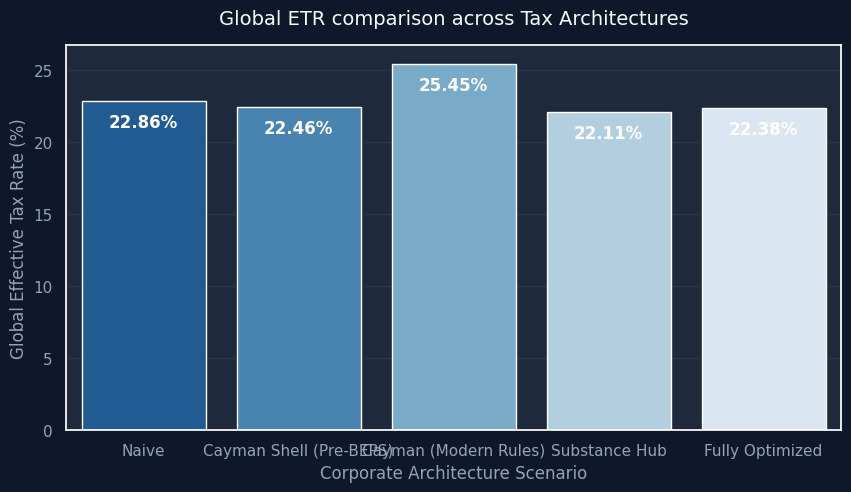

In [4]:
# Run Baseline Scenario Comparisons
engine = TaxEngine()
scenarios = {
    "Naive": ("US", 0.0, "US", 0.0, 0.0, True, True, True, False),
    "Cayman Shell (Pre-BEPS)": ("KY", 0.12, "KY", 0.09, 0.20, False, False, True, False),
    "Cayman (Modern Rules)": ("KY", 0.12, "KY", 0.09, 0.20, True, True, True, False),
    "Substance Hub": ("IE", 0.07, "CH", 0.04, 0.12, True, True, True, True),
    "Fully Optimized": ("IE", 0.06, "NL", 0.03, 0.10, True, True, True, True)
}

summary_data = []
for name, args in scenarios.items():
    _, etr, tax, pbt = engine.simulate(*args)
    summary_data.append({
        "Scenario": name,
        "Effective Tax Rate (%)": round(etr * 100, 2),
        "Global Tax Paid ($M)": round(tax / 1000000, 2),
        "Pre-Tax Profit ($M)": round(pbt / 1000000, 2)
    })

df_scen = pd.DataFrame(summary_data)
display(df_scen)

# Bar chart comparison of ETRs across scenarios
plt.figure(figsize=(10, 5))
ax = sns.barplot(x="Scenario", y="Effective Tax Rate (%)", data=df_scen, palette="Blues_r")
plt.title("Global ETR comparison across Tax Architectures", fontsize=14, color="#f8fafc", pad=15)
plt.ylabel("Global Effective Tax Rate (%)")
plt.xlabel("Corporate Architecture Scenario")
for p in ax.patches:
    ax.annotate(f"{p.get_height()}%", (p.get_x() + p.get_width() / 2., p.get_height() - 2),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', color='white', fontweight='bold')
plt.show()

In [5]:
# Interactive Sandbox Widget
def run_interactive(ip_dom, royalty_rate, fin_dom, interest_rate, tp_markup, p2_rule, gilti_rule, wht_rule, sg_holiday):
    engine = TaxEngine()
    entities, global_etr, total_tax, total_pbt = engine.simulate(
        ip_dom, royalty_rate, fin_dom, interest_rate, tp_markup, p2_rule, gilti_rule, wht_rule, sg_holiday
    )

    print(f"=========================================================")
    print(f" GLOBAL RESULTS: ETR = {global_etr*100:.2f}% | Total Tax = ${total_tax/1000000:.2f}M | PBT = ${total_pbt/1000000:.2f}M")
    print(f"=========================================================\n")

    # Display Ledger Table
    table_rows = []
    for code, ent in entities.items():
        local_etr = (ent["cit"] + ent["wht"]) / ent["taxable"] if ent["taxable"] > 0 else ent["cit_rate"]
        table_rows.append({
            "Entity": code,
            "CIT Rate (%)": f"{ent['cit_rate']*100:.1f}%",
            "Taxable Income ($M)": f"${ent['taxable']/1000000:.2f}M",
            "CIT Paid ($M)": f"${ent['cit']/1000000:.2f}M",
            "WHT Paid ($M)": f"${ent['wht']/1000000:.2f}M",
            "GILTI US ($M)": f"${ent['gilti']/1000000:.2f}M",
            "Effective Rate (%)": f"{local_etr*100:.2f}%"
        })
    display(pd.DataFrame(table_rows))

    # Double-Chart Render
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left Bar Chart: ETR vs 15% minimum
    codes = list(entities.keys())
    etrs = [((ent["cit"] + ent["wht"]) / ent["taxable"] * 100 if ent["taxable"] > 0 else ent["cit_rate"]*100) for ent in entities.values()]
    colors = ['#f43f5e' if (v < 15.0 and p2_rule and entities[c]['taxable'] > 0) else '#38bdf8' for c, v in zip(codes, etrs)]

    ax1.bar(codes, etrs, color=colors, edgecolor='white', alpha=0.85)
    ax1.axhline(15, color='#f43f5e', linestyle='--', linewidth=2, label='Pillar Two Minimum (15%)')
    ax1.set_title("Entity Effective Tax Rates", fontsize=12, color='white')
    ax1.set_ylabel("ETR (%)")
    ax1.legend()

    # Right Pie Chart: Global Tax Distribution
    tax_shares = [ent["total_tax"] for ent in entities.values() if ent["total_tax"] > 0]
    labels = [code for code, ent in entities.items() if ent["total_tax"] > 0]
    if sum(tax_shares) > 0:
        ax2.pie(tax_shares, labels=labels, autopct='%1.1f%%', colors=sns.color_palette("Blues_r", len(tax_shares)),
                textprops={'color': 'white', 'weight':'bold'})
        ax2.set_title("Corporate Income Tax Distribution", fontsize=12, color='white')
    else:
        ax2.text(0.5, 0.5, "No Taxes Paid (0% ETR)", ha='center', va='center', color='white')
        ax2.set_title("Corporate Income Tax Distribution", fontsize=12, color='white')

    plt.tight_layout()
    plt.show()

# Wire widgets
interactive_plot = interactive(
    run_interactive,
    ip_dom=widgets.Dropdown(options=['US', 'IE', 'CH', 'KY'], value='IE', description='IP Domicile'),
    royalty_rate=widgets.FloatSlider(min=0.0, max=0.15, step=0.005, value=0.06, description='Royalty Rate'),
    fin_dom=widgets.Dropdown(options=['US', 'NL', 'CH', 'KY'], value='NL', description='Lender Co'),
    interest_rate=widgets.FloatSlider(min=0.0, max=0.10, step=0.005, value=0.03, description='Interest Rate'),
    tp_markup=widgets.FloatSlider(min=0.05, max=0.30, step=0.01, value=0.10, description='TP Markup'),
    p2_rule=widgets.Checkbox(value=True, description='Pillar Two (15%)'),
    gilti_rule=widgets.Checkbox(value=True, description='US GILTI'),
    wht_rule=widgets.Checkbox(value=True, description='WHT Treaties'),
    sg_holiday=widgets.Checkbox(value=True, description='Singapore 10% CIT')
)

display(interactive_plot)

interactive(children=(Dropdown(description='IP Domicile', index=1, options=('US', 'IE', 'CH', 'KY'), value='IE…